#### 0) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import itertools

#### 1) Configurations

In [2]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

tickers = ["AAPL", "META", "MSFT", "TSLA"]
baseline_strat = "final_position_EMA"

# Assuming 5bps transaction cost and 1bps slippage per execution to match Notebook 3
# Applied whenever the position changes.
EXECUTION_DRAG = 0.0006 

In [3]:

print("PORTFOLIO CONSTRUCTION MECHANICS: DAILY EQUAL WEIGHT")
print("==========================================================")
print("This portfolio assumes a daily-rebalanced equal weight methodology.")
print("At the close of each day, the total portfolio equity is redistributed")
print("evenly across the four assets (25% each).")
print("")
print("Crucially, this is distinct from entry-triggered position sizing.")
print("Even if an asset is not actively in a 'Long' trade, its 25% allocation")
print("is held in cash (earning 0%), preventing capital from being overallocated")
print("to the remaining active trades. This enforces strict risk isolation.")
print("==========================================================\n")

PORTFOLIO CONSTRUCTION MECHANICS: DAILY EQUAL WEIGHT
This portfolio assumes a daily-rebalanced equal weight methodology.
At the close of each day, the total portfolio equity is redistributed
evenly across the four assets (25% each).

Crucially, this is distinct from entry-triggered position sizing.
Even if an asset is not actively in a 'Long' trade, its 25% allocation
is held in cash (earning 0%), preventing capital from being overallocated
to the remaining active trades. This enforces strict risk isolation.



#### 2) Daily Return Generation & Portfolio Construction 

In [5]:
strategy_returns = {}

for ticker in tickers:
    df = pd.read_parquet(output_dir / f"signals_{ticker}.parquet")
    
    # Daily asset return
    daily_asset_return = df['Close'].pct_change()
    
    # Strategy return (Shifted by 1 to represent executing at yesterday's close/today's open)
    strat_return = daily_asset_return * df[baseline_strat].shift(1)
    
    # Apply execution drag (Transaction Cost + Slippage) on days the position changes
    position_changes = df[baseline_strat].diff().abs()
    strat_return = np.where(position_changes == 1, strat_return - EXECUTION_DRAG, strat_return)
    
    # Store the pandas Series (which retains the Date index)
    strategy_returns[ticker] = pd.Series(strat_return, index=df.index)

# FIX: Use pd.concat to align the differing lengths by their Date index
df_returns_all = pd.concat(strategy_returns, axis=1).dropna()

# Calculate Portfolio Return (Daily Equal Weight)
df_portfolio = pd.DataFrame({
    'Portfolio': df_returns_all.mean(axis=1)
})

# Save the time-series arrays for Notebooks 6-9
df_returns_all.to_parquet(output_dir / "strategy_returns_all.parquet")
df_portfolio.to_parquet(output_dir / "portfolio_returns.parquet")

print(f"Panel successfully built from {df_returns_all.index.min().date()} to {df_returns_all.index.max().date()}")
print("Saved: strategy_returns_all.parquet")
print("Saved: portfolio_returns.parquet")

Panel successfully built from 2012-05-22 to 2025-12-30
Saved: strategy_returns_all.parquet
Saved: portfolio_returns.parquet


#### 3) Equity Curves

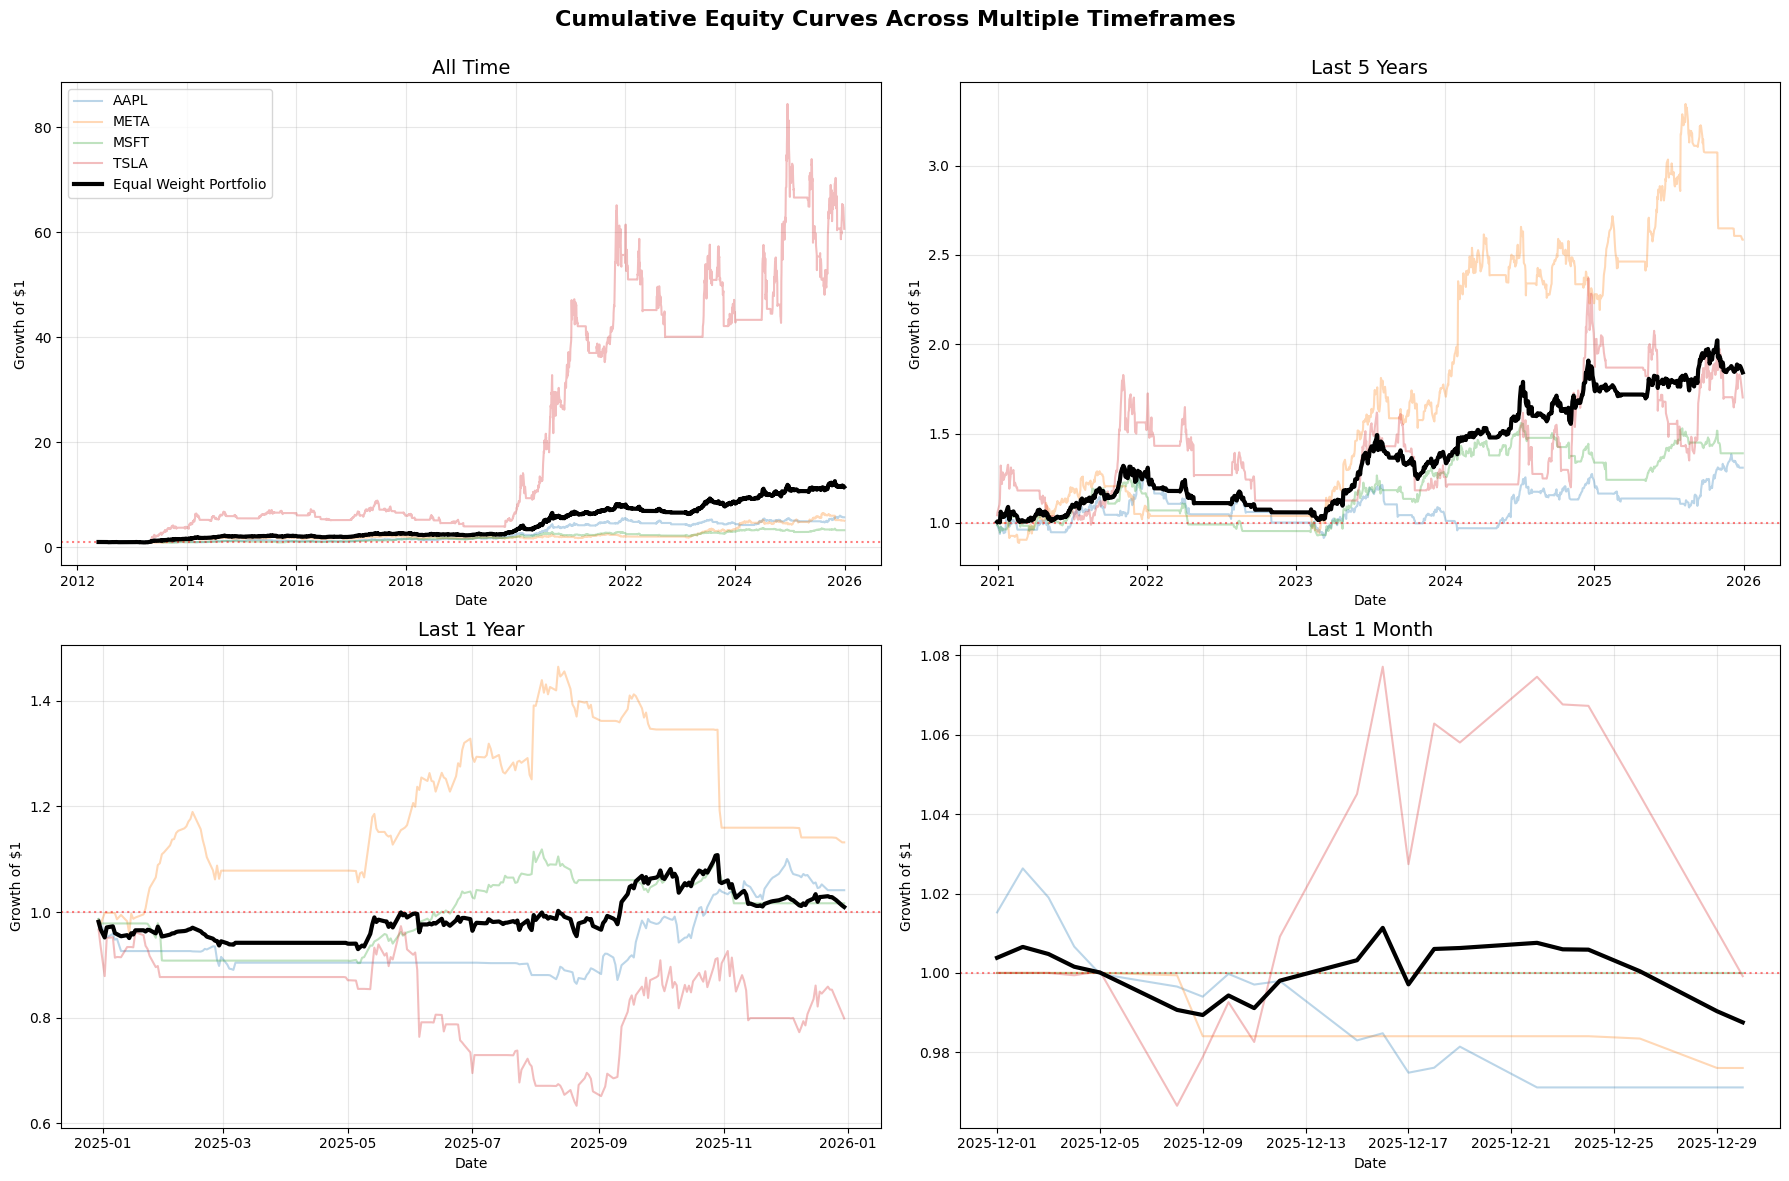

In [8]:
# Identify the most recent date in the dataset to calculate lookbacks
max_date = df_returns_all.index.max()

# Define the starting dates for our subplots
timeframes = {
    "All Time": None,
    "Last 5 Years": max_date - pd.DateOffset(years=5),
    "Last 1 Year": max_date - pd.DateOffset(years=1),
    "Last 1 Month": max_date - pd.DateOffset(months=1)
}

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Cumulative Equity Curves Across Multiple Timeframes", fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, (title, start_date) in zip(axes, timeframes.items()):
    
    # Slice the daily returns data for the specific timeframe
    if start_date is None:
        df_slice = df_returns_all.copy()
        port_slice = df_portfolio.copy()
    else:
        df_slice = df_returns_all[df_returns_all.index >= start_date].copy()
        port_slice = df_portfolio[df_portfolio.index >= start_date].copy()
        
    # Recalculate cumulative returns so each subplot starts exactly at $1.00
    cum_returns_slice = (1 + df_slice).cumprod()
    cum_port_slice = (1 + port_slice).cumprod()
    
    # Plot individual components
    for ticker in tickers:
        ax.plot(cum_returns_slice.index, cum_returns_slice[ticker], alpha=0.3, linewidth=1.5, label=f"{ticker}")
        
    # Plot Portfolio prominently
    ax.plot(cum_port_slice.index, cum_port_slice['Portfolio'], color='black', linewidth=3, zorder=10, label="Equal Weight Portfolio")
    
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Growth of $1")
    ax.set_xlabel("Date")
    ax.grid(alpha=0.3)
    
    # Only show the legend on the first subplot to reduce clutter
    if title == "All Time":
        ax.legend(loc="upper left")

plt.tight_layout()
plt.subplots_adjust(top=0.92) 
plt.show()

#### 4) 6-Month Rolling Correlation Heatmap

C:\Users\Hassa\AppData\Local\Temp\ipykernel_25592\3068461176.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_rolling_corr_monthly = df_rolling_corr.resample('M').mean().T


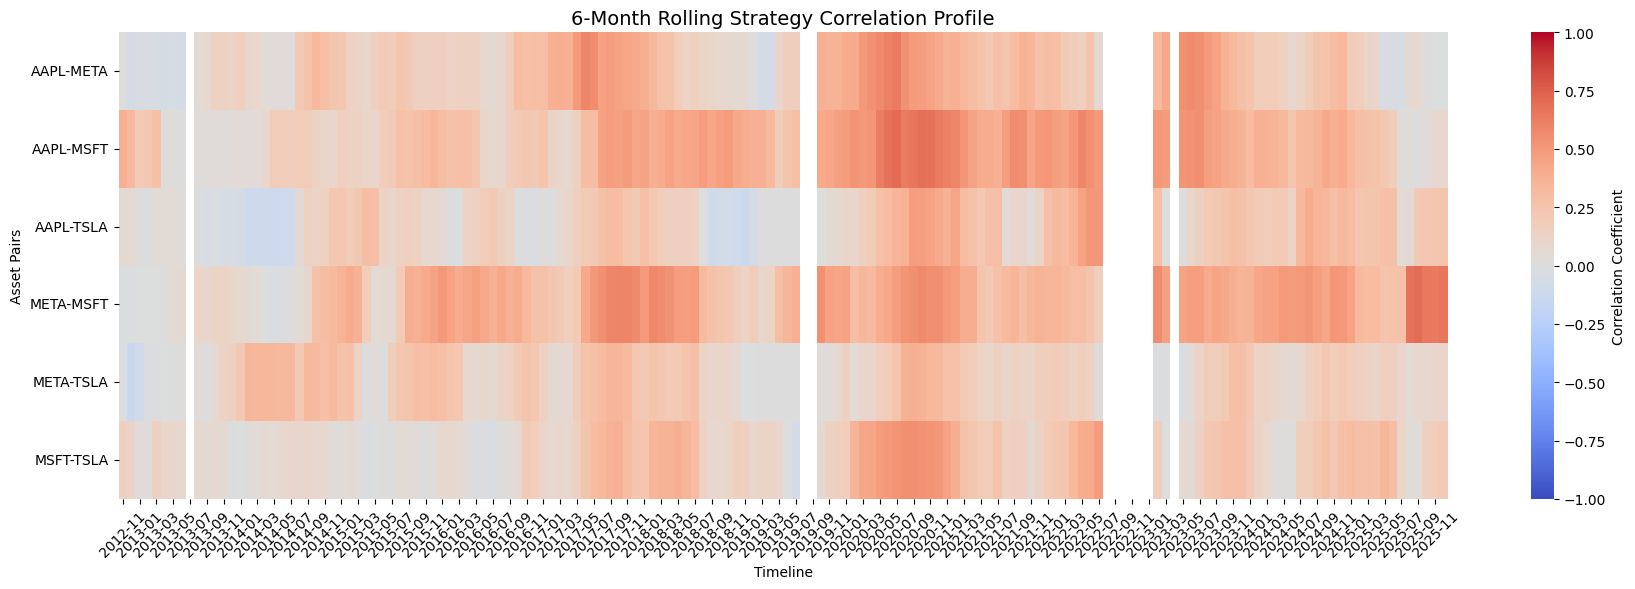

In [10]:
# Calculate 126-day rolling correlation for all unique pairs
pairs = list(itertools.combinations(tickers, 2))
rolling_corr_dict = {}

for pair in pairs:
    # 126 trading days ~ 6 months
    rolling_corr = df_returns_all[pair[0]].rolling(window=126).corr(df_returns_all[pair[1]])
    pair_name = f"{pair[0]}-{pair[1]}"
    rolling_corr_dict[pair_name] = rolling_corr

df_rolling_corr = pd.DataFrame(rolling_corr_dict).dropna()

# Resample to monthly for a cleaner heatmap visual
df_rolling_corr_monthly = df_rolling_corr.resample('M').mean().T
df_rolling_corr_monthly.columns = df_rolling_corr_monthly.columns.strftime('%Y-%m')

plt.figure(figsize=(18, 6))
sns.heatmap(df_rolling_corr_monthly, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title("6-Month Rolling Strategy Correlation Profile", fontsize=14)
plt.xlabel("Timeline")
plt.ylabel("Asset Pairs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5) Yearly Contribution Stacked Bar

C:\Users\Hassa\AppData\Local\Temp\ipykernel_25592\2275523821.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_returns = df_returns_all.resample('Y').sum() * 100 # Convert to percentage
C:\Users\Hassa\AppData\Local\Temp\ipykernel_25592\2275523821.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_port_return = df_portfolio.resample('Y').sum() * 100


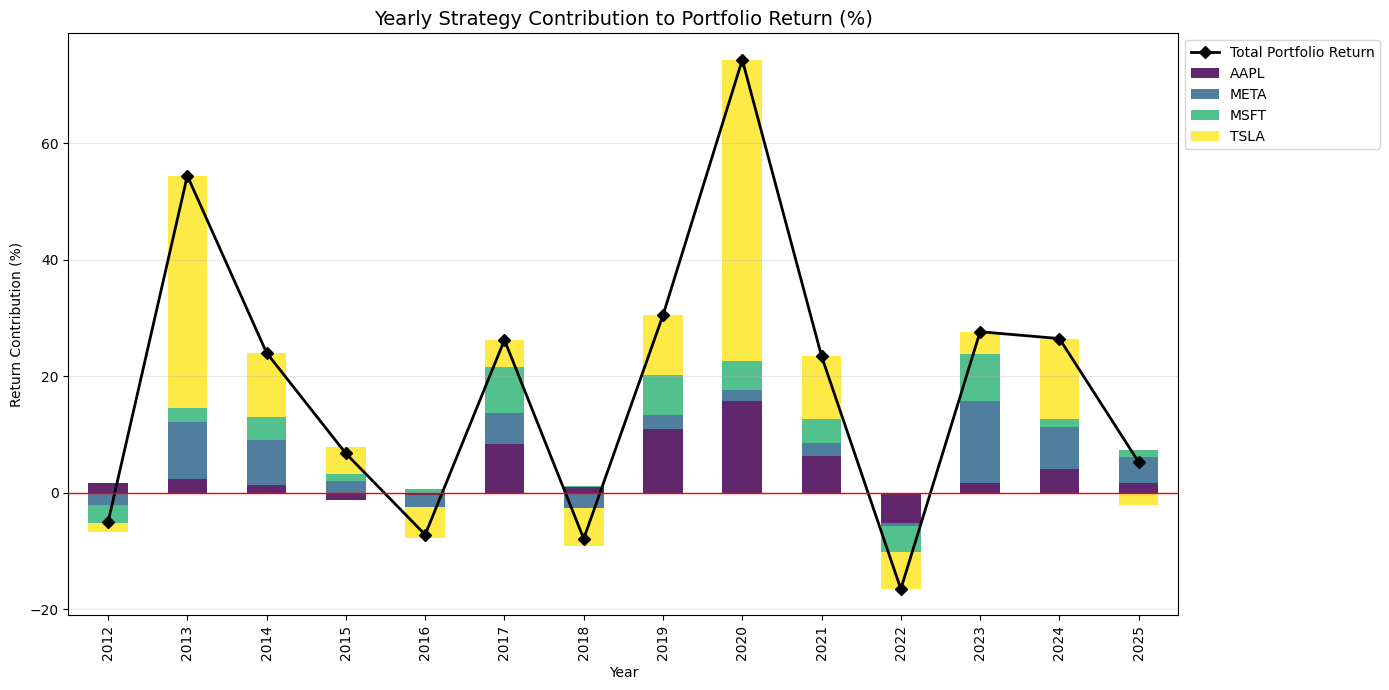

In [11]:
# Resample daily returns to yearly sums (approximation of additive contribution)
yearly_returns = df_returns_all.resample('Y').sum() * 100 # Convert to percentage
yearly_returns.index = yearly_returns.index.year

# Because the portfolio is 25% equal weight, the contribution of an asset 
# to the total portfolio return is its return divided by 4
yearly_contribution = yearly_returns / len(tickers)

ax = yearly_contribution.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', alpha=0.85)

# Overlay total portfolio line
yearly_port_return = df_portfolio.resample('Y').sum() * 100
ax.plot(range(len(yearly_port_return)), yearly_port_return['Portfolio'], 
        color='black', marker='D', linewidth=2, label='Total Portfolio Return')

plt.title("Yearly Strategy Contribution to Portfolio Return (%)", fontsize=14)
plt.ylabel("Return Contribution (%)")
plt.xlabel("Year")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 7) Drawdown Synchronization Plot

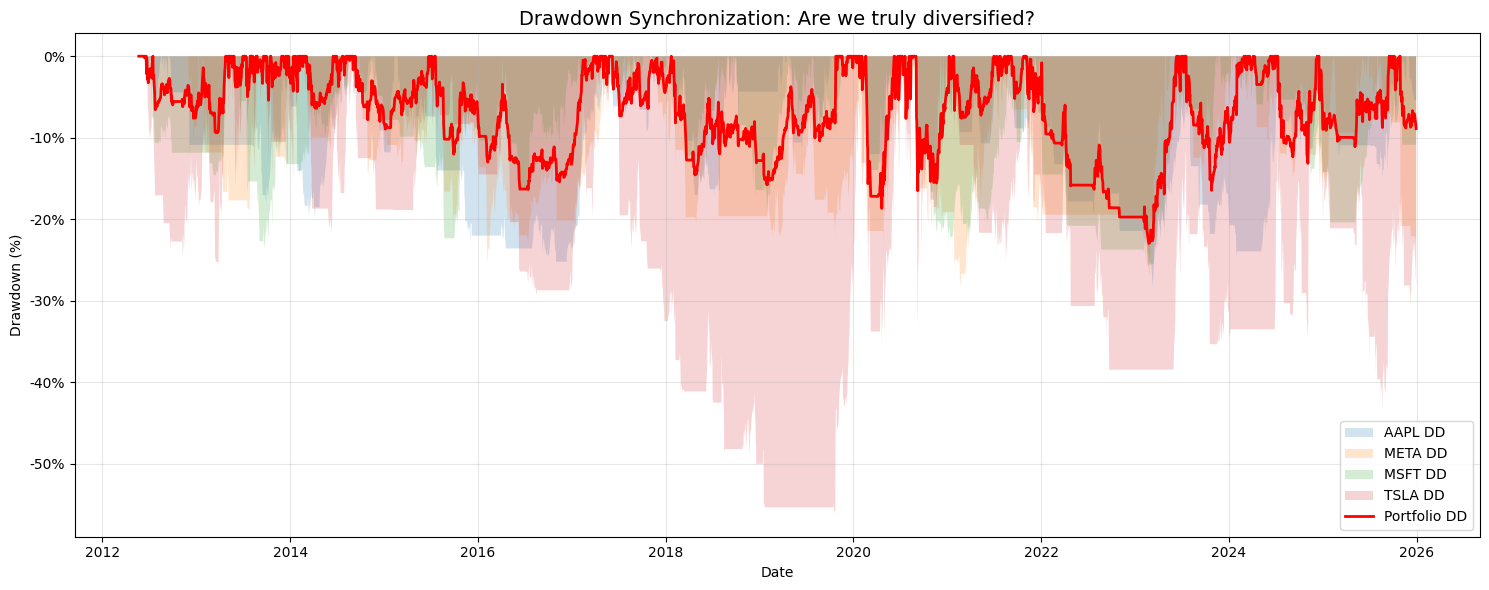

In [13]:
# Calculate Drawdowns
def calculate_drawdown(cum_ret_series):
    rolling_max = cum_ret_series.cummax()
    drawdown = (cum_ret_series - rolling_max) / rolling_max
    return drawdown

drawdowns_all = cum_returns_all.apply(calculate_drawdown)
drawdown_port = calculate_drawdown(cum_return_port['Portfolio'])

plt.figure(figsize=(15, 6))

# Plot Individual Drawdowns
for ticker in tickers:
    plt.fill_between(drawdowns_all.index, drawdowns_all[ticker], 0, alpha=0.2, label=f"{ticker} DD")

# Plot Portfolio Drawdown prominently
plt.plot(drawdown_port.index, drawdown_port, color='red', linewidth=2, label="Portfolio DD")

plt.title("Drawdown Synchronization: Are we truly diversified?", fontsize=14)
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
# Format Y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()